In [13]:
%autosave 60

Autosaving every 60 seconds


# RAG: чанкинг и reranker

Итеративная разработка RAG для PDF Ростехнадзор: сравниваем качество при **простом разбиении на чанки** (baseline), **разбиении по нумерованным пунктам** (chunk_by_points), добавлении **reranker** и их комбинации. Метрики retrieval (recall@k, MRR) и generation (ROUGE, BLEU, BERTScore) считаются на едином бенчмарке.

## Настройка окружения

Загружаем `.env`, подключаем модели из `config`, инициализируем LLM (Open Router) и эмбеддинги. Данные — только PDF Ростехнадзор (`data_v2.pdf`).

In [14]:
import os
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

env_path = PROJECT_ROOT / ".env"
if env_path.exists():
    from dotenv import load_dotenv
    load_dotenv(env_path)

from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document

from config import model_llm, model_embedding

PATH_PDF = PROJECT_ROOT / "data" / "text" / "data_v2.pdf"

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
    model=model_llm,
    default_headers={"X-Title": "RAG Chunking Notebook"},
)
embeddings = HuggingFaceEmbeddings(model_name=model_embedding)

print("Окружение готово. LLM:", model_llm, "| Эмбеддинги:", model_embedding)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1768.64it/s, Materializing param=pooler.dense.weight]                               


Окружение готово. LLM: google/gemini-3.1-flash-lite-preview | Эмбеддинги: baai/bge-m3


## 1) Исходный замер качества (baseline)

Загружаем PDF, разбиваем **RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)** как в [2.0]. Загружаем бенчмарк из артефактов и добавляем в каждый сэмпл текст эталонного чанка (`reference_chunk_text`) для последующего сравнения при другом чанкинге. Собираем RAG и считаем retrieval и generation метрики.

In [3]:
# Загрузка PDF и baseline-чанкинг
loader_pdf = PyPDFLoader(str(PATH_PDF))
docs_pdf_raw = loader_pdf.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits_pdf = text_splitter.split_documents(docs_pdf_raw)
for i, doc in enumerate(splits_pdf):
    doc.metadata["chunk_idx"] = i

artifacts_dir = PROJECT_ROOT / "notebooks_rag" / "artifacts"
with open(artifacts_dir / "samples_pdf.json", "r", encoding="utf-8") as f:
    samples_pdf = json.load(f)

# Обогащение сэмплов текстом эталонного чанка (для сравнения при chunk_by_points)
for s in samples_pdf:
    idx = s["chunk_idx"]
    s["reference_chunk_text"] = splits_pdf[idx].page_content

print("Чанков (baseline):", len(splits_pdf), "| Сэмплов в бенчмарке:", len(samples_pdf))

Чанков (baseline): 1300 | Сэмплов в бенчмарке: 25


In [4]:
# Сборка baseline RAG
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

system_prompt = (
    "Ты — полезный ИИ-ассистент. Используй следующий контекст для ответа на вопрос пользователя. "
    "Если ответа в контексте нет, так и скажи.\n\nКонтекст: {context}"
)
prompt_rag = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{question}"),
])

vectorstore_pdf = Chroma.from_documents(
    documents=splits_pdf,
    embedding=embeddings,
    collection_name="rag_chunking_baseline",
)
retriever_pdf = vectorstore_pdf.as_retriever(search_kwargs={"k": 10})
rag_chain_pdf = (
    {"context": retriever_pdf | format_docs, "question": RunnablePassthrough()}
    | prompt_rag
    | llm
    | StrOutputParser()
)
print("Baseline RAG собран (retriever k=10).")

Baseline RAG собран (retriever k=10).


In [5]:
# Retrieval-метрики (baseline): recall@k, MRR по chunk_idx
from rouge_score import rouge_scorer
import sacrebleu
from bert_score import score as bert_score_fun

K_LIST = [1, 3, 5, 10]
retrieval_rows = []
for i, s in enumerate(samples_pdf):
    retrieved = retriever_pdf.invoke(s["question"])
    retrieved_indices = [d.metadata.get("chunk_idx", -1) for d in retrieved]
    rel_idx = s["chunk_idx"]
    rank = 0
    for pos, idx in enumerate(retrieved_indices, 1):
        if idx == rel_idx:
            rank = pos
            break
    recall_at_k = {f"recall@{k}": (1.0 if rel_idx in retrieved_indices[:k] else 0.0) for k in K_LIST}
    mrr = 1.0 / rank if rank else 0.0
    retrieval_rows.append({"sample_id": i, **recall_at_k, "mrr": mrr})

df_ret_baseline = pd.DataFrame(retrieval_rows)
means_ret_baseline = df_ret_baseline.drop(columns=["sample_id"]).mean()
print("Retrieval (baseline), средние:")
print(means_ret_baseline.to_string())
df_ret_baseline

Retrieval (baseline), средние:
recall@1     0.640000
recall@3     0.880000
recall@5     0.960000
recall@10    0.960000
mrr          0.771333


,sample_id,recall@1,recall@3,recall@5,recall@10,mrr
0,0,0.0,0.0,1.0,1.0,0.200000
1,1,1.0,1.0,1.0,1.0,1.000000
2,2,1.0,1.0,1.0,1.0,1.000000
3,3,0.0,1.0,1.0,1.0,0.500000
4,4,0.0,1.0,1.0,1.0,0.333333
5,5,1.0,1.0,1.0,1.0,1.000000
6,6,1.0,1.0,1.0,1.0,1.000000
7,7,0.0,1.0,1.0,1.0,0.500000
8,8,1.0,1.0,1.0,1.0,1.000000
9,9,1.0,1.0,1.0,1.0,1.000000


In [6]:
# Generation-метрики (baseline)
rouge = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
answers_baseline = [rag_chain_pdf.invoke(s["question"]) for s in samples_pdf]
refs_pdf = [s["ground_truth"][:500] for s in samples_pdf]
gen_rows = []
for i, (answer, ref) in enumerate(zip(answers_baseline, refs_pdf)):
    r1 = rouge.score(ref, answer)["rouge1"].fmeasure
    rL = rouge.score(ref, answer)["rougeL"].fmeasure
    bleu = sacrebleu.sentence_bleu(answer, [ref], smooth_method="exp").score / 100.0
    gen_rows.append({"sample_id": i, "rouge1_f": r1, "rougeL_f": rL, "bleu": bleu})
df_gen_baseline = pd.DataFrame(gen_rows)
_, _, F1 = bert_score_fun(cands=answers_baseline, refs=refs_pdf, lang="ru", verbose=False)
df_gen_baseline["bertscore_f1"] = F1.numpy()
means_gen_baseline = df_gen_baseline.drop(columns=["sample_id"]).mean()
print("Generation (baseline), средние:")
print(means_gen_baseline.to_string())
df_gen_baseline

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1362.93it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generation (baseline), средние:
rouge1_f        0.224308
rougeL_f        0.204574
bleu            0.107267
bertscore_f1    0.757070


,sample_id,rouge1_f,rougeL_f,bleu,bertscore_f1
0,0,0.307692,0.307692,0.009704,0.698259
1,1,0.500000,0.500000,0.074071,0.730337
2,2,0.000000,0.000000,0.016666,0.772430
3,3,0.000000,0.000000,0.050821,0.708053
4,4,0.000000,0.000000,0.025074,0.777929
5,5,0.000000,0.000000,0.080998,0.727832
6,6,0.000000,0.000000,0.161040,0.794269
7,7,0.000000,0.000000,0.059385,0.726654
8,8,0.000000,0.000000,0.014367,0.720202
9,9,0.000000,0.000000,0.151085,0.762300


,значение
recall@1,0.640000
recall@3,0.880000
recall@5,0.960000
recall@10,0.960000
mrr,0.771333
rouge1_f,0.224308
rougeL_f,0.204574
bleu,0.107267
bertscore_f1,0.757070


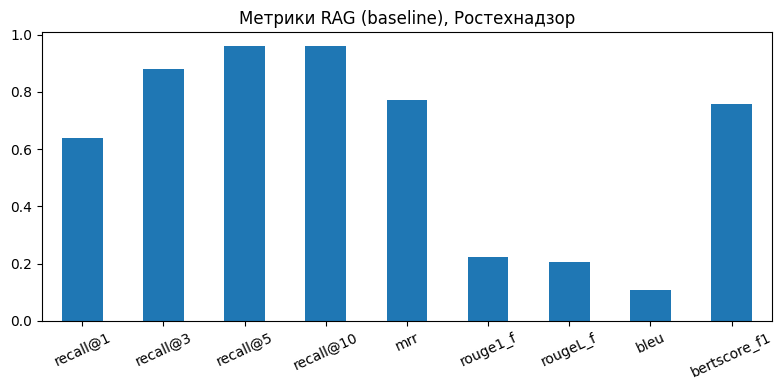

--- Пример ---
Вопрос: Каковы требования к высоте подвески контактного провода над головкой рельса на путях технологического железнодорожного транспорта? 
Эталон: Высота подвески должна составлять не менее 6250 мм на станционных путях и не менее 5750 мм на перегонах. Данные параметры должны строго соответствовать проектной документации. 
Ответ RAG: Требования к высоте подвески контактного провода на путях технологического железнодорожного транспорта согласно представленному тексту:

*   **На постоянных путях:**
    *   На станциях — не менее **6 ...
Метрики по примеру: rouge1_f=0.3077, bertscore_f1=0.6983


In [7]:
# Сводка baseline и один пример
import matplotlib.pyplot as plt

metrics_baseline = pd.concat([means_ret_baseline, means_gen_baseline])
display(metrics_baseline.to_frame("значение"))
metrics_baseline.plot(kind="bar", figsize=(8, 4), title="Метрики RAG (baseline), Ростехнадзор")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

ex = samples_pdf[0]
print("--- Пример ---")
print("Вопрос:", ex["question"][:150], "..." if len(ex["question"]) > 150 else "")
print("Эталон:", ex["ground_truth"][:200], "..." if len(ex["ground_truth"]) > 200 else "")
print("Ответ RAG:", answers_baseline[0][:200], "..." if len(answers_baseline[0]) > 200 else "")
print("Метрики по примеру: rouge1_f={:.4f}, bertscore_f1={:.4f}".format(
    df_gen_baseline.iloc[0]["rouge1_f"], df_gen_baseline.iloc[0]["bertscore_f1"]))

### Чанкинг
Чанкование (chunking) — это процесс разбиения исходного текста на небольшие, осмысленные фрагменты (чанки), которые используются в системах RAG (Retrieval-Augmented Generation) для эффективного поиска и извлечения релевантной информации. Размер чанка подбирается так, чтобы он сохранял контекст, но не был слишком большим для обработки моделью при векторизации. 


![RAG схема](img/chunk_1.png)


Часто применяют технику overlap chunking — перекрывающееся чанкование, при котором соседние чанки частично повторяют друг друга (например, overlap 10–20%). Это помогает избежать потери смысла на границах чанков, когда важная информация оказывается «разрезанной» между ними, и таким образом повышает качество генерации и точность поиска в RAG-пайплайне.


![RAG схема](img/chunk_2.png)


## 2) Более правильный чанкинг (chunk_by_points)

Разбиение по **нумерованным пунктам** сохраняет смысловые границы: в нормативных текстах (как Ростехнадзор) структура «1. …», «2. …» часто соответствует логическим блокам. Используем функцию `chunk_by_points` из `src.common` (паттерн `\n(\d+\.\s+[A-Яа-яA-Za-z])`): склеиваем страницы PDF в один текст и режем по этим границам.

In [8]:
# Чанкинг по пунктам для PDF
from src.common import chunk_by_points

text_pdf_full = "".join(d.page_content for d in docs_pdf_raw)
chunk_texts = chunk_by_points(text_pdf_full)

splits_points = []
for i, c in enumerate(chunk_texts):
    if not c.strip():
        continue
    splits_points.append(Document(page_content=c.strip(), metadata={"chunk_idx": len(splits_points)}))

# Переприсвоить chunk_idx подряд (на случай пропусков)
for i, doc in enumerate(splits_points):
    doc.metadata["chunk_idx"] = i

lengths = [len(d.page_content) for d in splits_points]
print("Чанков (chunk_by_points):", len(splits_points))
print("Длина: min={}, max={}, mean={:.0f}".format(min(lengths), max(lengths), np.mean(lengths)))
print("Сравнение: baseline", len(splits_pdf), "чанков → chunk_by_points", len(splits_points), "чанков")

Чанков (chunk_by_points): 1788
Длина: min=15, max=10381, mean=537
Сравнение: baseline 1300 чанков → chunk_by_points 1788 чанков


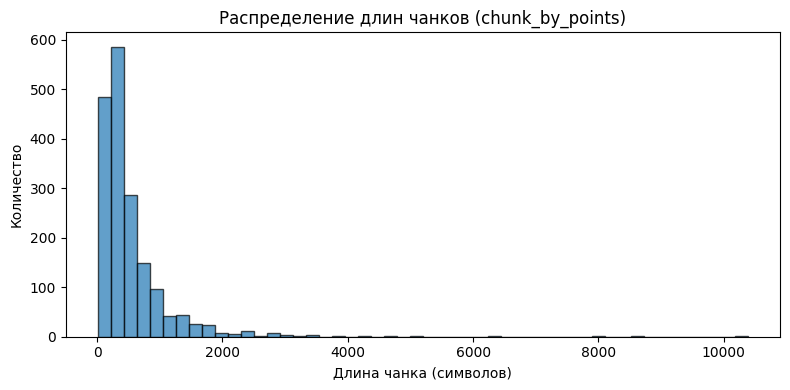

In [9]:
# Распределение длин чанков (chunk_by_points)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Длина чанка (символов)")
ax.set_ylabel("Количество")
ax.set_title("Распределение длин чанков (chunk_by_points)")
plt.tight_layout()
plt.show()

## 3) Замер качества после улучшенного чанкинга

Собираем RAG на сплитах `chunk_by_points`. Релевантность для retrieval определяем по перекрытию с эталонным текстом чанка: считаем hit, если среди top-k есть документ, содержащий эталонный текст или с достаточным перекрытием по подстрокам.

In [10]:
# RAG на сплитах chunk_by_points
vectorstore_points = Chroma.from_documents(
    documents=splits_points,
    embedding=embeddings,
    collection_name="rag_chunking_points",
)
retriever_points = vectorstore_points.as_retriever(search_kwargs={"k": 10})
rag_chain_points = (
    {"context": retriever_points | format_docs, "question": RunnablePassthrough()}
    | prompt_rag
    | llm
    | StrOutputParser()
)

def doc_matches_reference(doc_content, ref_text, min_overlap_ratio=0.3):
    """Релевантен ли документ эталонному чанку: вхождение или достаточное перекрытие слов."""
    if not ref_text or not ref_text.strip():
        return False
    if ref_text.strip() in doc_content:
        return True
    ref_words = set(ref_text.split())
    doc_words = set(doc_content.split())
    if not ref_words:
        return False
    overlap = len(ref_words & doc_words) / len(ref_words)
    return overlap >= min_overlap_ratio

# Retrieval по перекрытию с reference_chunk_text
retrieval_rows_pts = []
for i, s in enumerate(samples_pdf):
    retrieved = retriever_points.invoke(s["question"])
    ref_text = s.get("reference_chunk_text", "")
    rank = 0
    for pos, doc in enumerate(retrieved, 1):
        if doc_matches_reference(doc.page_content, ref_text):
            rank = pos
            break
    recall_at_k = {}
    for k in K_LIST:
        found = any(doc_matches_reference(d.page_content, ref_text) for d in retrieved[:k])
        recall_at_k[f"recall@{k}"] = 1.0 if found else 0.0
    mrr = 1.0 / rank if rank else 0.0
    retrieval_rows_pts.append({"sample_id": i, **recall_at_k, "mrr": mrr})

df_ret_points = pd.DataFrame(retrieval_rows_pts)
means_ret_points = df_ret_points.drop(columns=["sample_id"]).mean()
print("Retrieval (chunk_by_points), средние:")
print(means_ret_points.to_string())

Retrieval (chunk_by_points), средние:
recall@1     0.640000
recall@3     0.720000
recall@5     0.800000
recall@10    0.800000
mrr          0.684667


In [11]:
# Generation-метрики для chunk_by_points
answers_points = [rag_chain_points.invoke(s["question"]) for s in samples_pdf]
gen_rows_pts = []
for i, (answer, ref) in enumerate(zip(answers_points, refs_pdf)):
    r1 = rouge.score(ref, answer)["rouge1"].fmeasure
    rL = rouge.score(ref, answer)["rougeL"].fmeasure
    bleu = sacrebleu.sentence_bleu(answer, [ref], smooth_method="exp").score / 100.0
    gen_rows_pts.append({"sample_id": i, "rouge1_f": r1, "rougeL_f": rL, "bleu": bleu})
df_gen_points = pd.DataFrame(gen_rows_pts)
_, _, F1_pts = bert_score_fun(cands=answers_points, refs=refs_pdf, lang="ru", verbose=False)
df_gen_points["bertscore_f1"] = F1_pts.numpy()
means_gen_points = df_gen_points.drop(columns=["sample_id"]).mean()
print("Generation (chunk_by_points), средние:")
print(means_gen_points.to_string())

# Сравнение с baseline
metrics_points = pd.concat([means_ret_points, means_gen_points])
comparison_1 = pd.DataFrame({"baseline": metrics_baseline, "chunk_by_points": metrics_points})
display(comparison_1)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2083.14it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generation (chunk_by_points), средние:
rouge1_f        0.196032
rougeL_f        0.185668
bleu            0.099362
bertscore_f1    0.734410


,baseline,chunk_by_points
recall@1,0.640000,0.640000
recall@3,0.880000,0.720000
recall@5,0.960000,0.800000
recall@10,0.960000,0.800000
mrr,0.771333,0.684667
rouge1_f,0.224308,0.196032
rougeL_f,0.204574,0.185668
bleu,0.107267,0.099362
bertscore_f1,0.757070,0.734410


## 4) Добавление reranker

**Reranker** переранжирует кандидаты от базового ретривера (по запросу и документу) и отдаёт в контекст только топ-N. Так мы уменьшаем шум и улучшаем релевантность контекста. Используем мультиязычную модель **BAAI/bge-reranker-v2-m3**: базовый retriever с k=15, после reranker — топ-3 документа (как в sample_rag.py).

![RAG схема](img/rerank.png)

In [15]:
# Reranker: CrossEncoder + ContextualCompressionRetriever
# В LangChain 1.2 с langchain_classic классы в langchain_classic, не в langchain
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

cross_encoder_model = HuggingFaceCrossEncoder(
    model_name="BAAI/bge-reranker-v2-m3",
    model_kwargs={"device": "cpu"},
)
reranker = CrossEncoderReranker(model=cross_encoder_model, top_n=3)

# Baseline retriever с k=15, затем reranker → 3 документа
base_retriever_baseline = vectorstore_pdf.as_retriever(search_kwargs={"k": 15})
compression_retriever_baseline = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=base_retriever_baseline,
)
rag_chain_baseline_reranker = (
    {"context": compression_retriever_baseline | format_docs, "question": RunnablePassthrough()}
    | prompt_rag
    | llm
    | StrOutputParser()
)
print("RAG baseline + reranker собран (k=15 → top 3).")

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 1798.60it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              


RAG baseline + reranker собран (k=15 → top 3).


## 5) Замер качества с reranker (baseline + reranker)

Считаем retrieval и generation для варианта «baseline + reranker». После reranker в контекст попадают только 3 документа; retrieval считаем по тем же правилам (chunk_idx для baseline-сплитов среди этих 3).

In [16]:
# Retrieval для baseline + reranker (топ-3 документа)
retrieval_rows_rerank = []
for i, s in enumerate(samples_pdf):
    retrieved = compression_retriever_baseline.invoke(s["question"])
    retrieved_indices = [d.metadata.get("chunk_idx", -1) for d in retrieved]
    rel_idx = s["chunk_idx"]
    rank = 0
    for pos, idx in enumerate(retrieved_indices, 1):
        if idx == rel_idx:
            rank = pos
            break
    # После reranker только 3 дока → recall@5, @10 совпадают с recall@3
    recall_at_k = {f"recall@{k}": (1.0 if rel_idx in retrieved_indices[:min(k, 3)] else 0.0) for k in K_LIST}
    mrr = 1.0 / rank if rank else 0.0
    retrieval_rows_rerank.append({"sample_id": i, **recall_at_k, "mrr": mrr})

df_ret_rerank = pd.DataFrame(retrieval_rows_rerank)
means_ret_rerank = df_ret_rerank.drop(columns=["sample_id"]).mean()
print("Retrieval (baseline + reranker), средние:")
print(means_ret_rerank.to_string())

# Generation
answers_rerank = [rag_chain_baseline_reranker.invoke(s["question"]) for s in samples_pdf]
gen_rows_rerank = []
for i, (answer, ref) in enumerate(zip(answers_rerank, refs_pdf)):
    r1 = rouge.score(ref, answer)["rouge1"].fmeasure
    rL = rouge.score(ref, answer)["rougeL"].fmeasure
    bleu = sacrebleu.sentence_bleu(answer, [ref], smooth_method="exp").score / 100.0
    gen_rows_rerank.append({"sample_id": i, "rouge1_f": r1, "rougeL_f": rL, "bleu": bleu})
df_gen_rerank = pd.DataFrame(gen_rows_rerank)
_, _, F1_rr = bert_score_fun(cands=answers_rerank, refs=refs_pdf, lang="ru", verbose=False)
df_gen_rerank["bertscore_f1"] = F1_rr.numpy()
means_gen_rerank = df_gen_rerank.drop(columns=["sample_id"]).mean()
print("Generation (baseline + reranker), средние:")
print(means_gen_rerank.to_string())

metrics_rerank = pd.concat([means_ret_rerank, means_gen_rerank])
comparison_2 = pd.DataFrame({
    "baseline": metrics_baseline,
    "chunk_by_points": metrics_points,
    "baseline+reranker": metrics_rerank,
})
display(comparison_2)

Retrieval (baseline + reranker), средние:
recall@1     0.760000
recall@3     0.920000
recall@5     0.920000
recall@10    0.920000
mrr          0.833333


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1943.06it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generation (baseline + reranker), средние:
rouge1_f        0.222338
rougeL_f        0.215065
bleu            0.136757
bertscore_f1    0.776684


,baseline,chunk_by_points,baseline+reranker
recall@1,0.640000,0.640000,0.760000
recall@3,0.880000,0.720000,0.920000
recall@5,0.960000,0.800000,0.920000
recall@10,0.960000,0.800000,0.920000
mrr,0.771333,0.684667,0.833333
rouge1_f,0.224308,0.196032,0.222338
rougeL_f,0.204574,0.185668,0.215065
bleu,0.107267,0.099362,0.136757
bertscore_f1,0.757070,0.734410,0.776684


## 6) Итоговое сравнение: chunk_by_points + reranker

Собираем RAG на сплитах chunk_by_points с reranker, считаем метрики и сводим все четыре конфигурации в одну таблицу и график.

In [17]:
# RAG: chunk_by_points + reranker
base_retriever_points = vectorstore_points.as_retriever(search_kwargs={"k": 15})
compression_retriever_points = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=base_retriever_points,
)
rag_chain_points_reranker = (
    {"context": compression_retriever_points | format_docs, "question": RunnablePassthrough()}
    | prompt_rag
    | llm
    | StrOutputParser()
)

# Retrieval по перекрытию с reference_chunk_text (топ-3 после reranker)
retrieval_rows_pt_rr = []
for i, s in enumerate(samples_pdf):
    retrieved = compression_retriever_points.invoke(s["question"])
    ref_text = s.get("reference_chunk_text", "")
    rank = 0
    for pos, doc in enumerate(retrieved, 1):
        if doc_matches_reference(doc.page_content, ref_text):
            rank = pos
            break
    recall_at_k = {}
    for k in K_LIST:
        found = any(doc_matches_reference(d.page_content, ref_text) for d in retrieved[:min(k, 3)])
        recall_at_k[f"recall@{k}"] = 1.0 if found else 0.0
    mrr = 1.0 / rank if rank else 0.0
    retrieval_rows_pt_rr.append({"sample_id": i, **recall_at_k, "mrr": mrr})

df_ret_pt_rr = pd.DataFrame(retrieval_rows_pt_rr)
means_ret_pt_rr = df_ret_pt_rr.drop(columns=["sample_id"]).mean()

# Generation
answers_pt_rr = [rag_chain_points_reranker.invoke(s["question"]) for s in samples_pdf]
gen_rows_pt_rr = []
for i, (answer, ref) in enumerate(zip(answers_pt_rr, refs_pdf)):
    r1 = rouge.score(ref, answer)["rouge1"].fmeasure
    rL = rouge.score(ref, answer)["rougeL"].fmeasure
    bleu = sacrebleu.sentence_bleu(answer, [ref], smooth_method="exp").score / 100.0
    gen_rows_pt_rr.append({"sample_id": i, "rouge1_f": r1, "rougeL_f": rL, "bleu": bleu})
df_gen_pt_rr = pd.DataFrame(gen_rows_pt_rr)
_, _, F1_pt_rr = bert_score_fun(cands=answers_pt_rr, refs=refs_pdf, lang="ru", verbose=False)
df_gen_pt_rr["bertscore_f1"] = F1_pt_rr.numpy()
means_gen_pt_rr = df_gen_pt_rr.drop(columns=["sample_id"]).mean()

metrics_pt_rr = pd.concat([means_ret_pt_rr, means_gen_pt_rr])
print("Метрики (chunk_by_points + reranker):")
print(metrics_pt_rr.to_string())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2079.54it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Метрики (chunk_by_points + reranker):
recall@1        0.600000
recall@3        0.840000
recall@5        0.840000
recall@10       0.840000
mrr             0.700000
rouge1_f        0.229495
rougeL_f        0.214330
bleu            0.103717
bertscore_f1    0.747008


,Baseline,Chunk_by_points,Baseline+Reranker,Chunk_by_points+Reranker
recall@1,0.640000,0.640000,0.760000,0.600000
recall@3,0.880000,0.720000,0.920000,0.840000
recall@5,0.960000,0.800000,0.920000,0.840000
recall@10,0.960000,0.800000,0.920000,0.840000
mrr,0.771333,0.684667,0.833333,0.700000
rouge1_f,0.224308,0.196032,0.222338,0.229495
rougeL_f,0.204574,0.185668,0.215065,0.214330
bleu,0.107267,0.099362,0.136757,0.103717
bertscore_f1,0.757070,0.734410,0.776684,0.747008


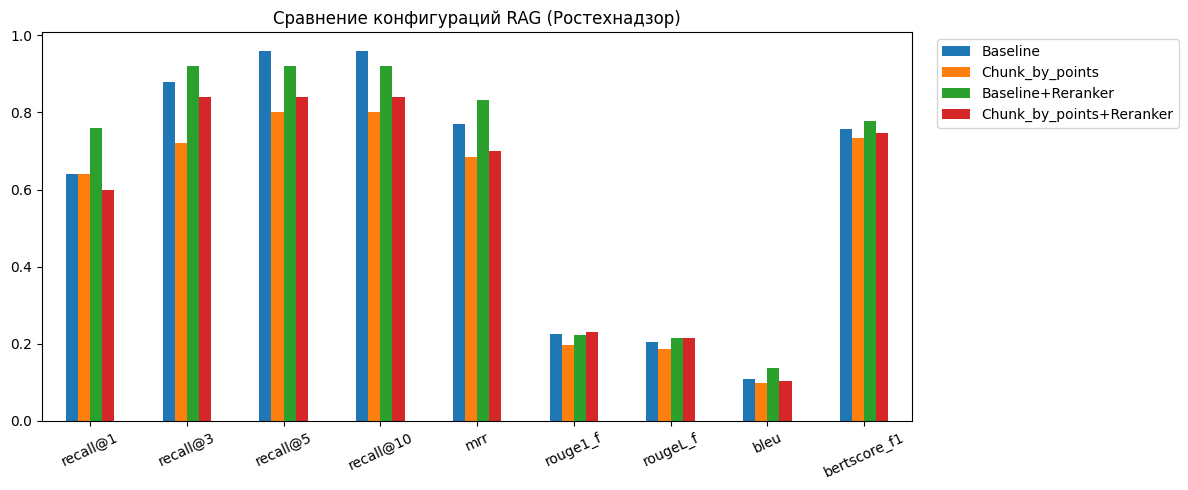

In [18]:
# Итоговая сводная таблица по всем конфигурациям
final_comparison = pd.DataFrame({
    "Baseline": metrics_baseline,
    "Chunk_by_points": metrics_points,
    "Baseline+Reranker": metrics_rerank,
    "Chunk_by_points+Reranker": metrics_pt_rr,
})
display(final_comparison)

# График: по оси X — метрики, по столбцам — конфигурации
final_comparison.plot(kind="bar", figsize=(12, 5), title="Сравнение конфигураций RAG (Ростехнадзор)")
plt.xticks(rotation=25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
# Сохранение сводных метрик для воспроизводимости
artifacts_dir.mkdir(parents=True, exist_ok=True)
with open(artifacts_dir / "rag_chunking_metrics.json", "w", encoding="utf-8") as f:
    json.dump(final_comparison.to_dict(), f, ensure_ascii=False, indent=2)
print("Сохранено:", artifacts_dir / "rag_chunking_metrics.json")

Сохранено: /Users/maxim/Desktop/STUDY/ai_agents_course/notebooks_rag/artifacts/rag_chunking_metrics.json


### Выводы

- **Baseline** — исходное качество при простом чанкинге (RecursiveCharacterTextSplitter) без reranker.
- **Chunk_by_points** — разбиение по нумерованным пунктам может улучшить retrieval (более цельные смысловые блоки) и за счёт этого generation.
- **Reranker** отбирает из большего пула (k=15) топ-3 наиболее релевантных документа, что обычно повышает качество ответов при том же чанкинге.
- **Chunk_by_points + Reranker** — комбинация даёт возможность получить прирост и от границ чанков, и от переранжирования; итоговое сравнение в таблице выше показывает, какой вклад вносит каждое улучшение.